# MovieLens 1M — Exploratory Data Analysis

Анализируем три таблицы:
- `ratings.dat` — оценки пользователей (user_id, movie_id, rating, timestamp)
- `movies.dat` — информация о фильмах (movie_id, title, genres)
- `users.dat` — демография (user_id, gender, age, occupation, zip)

Цели EDA:
1. Понять распределение данных
2. Выявить cold-start проблему
3. Обосновать temporal split
4. Собрать фичи для 2-й стадии (ранжирование)

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.ticker import FormatStrFormatter
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 100

DATA_DIR = Path('../data/ml-1m')

## 1. Загрузка данных

In [2]:
# Ratings
ratings = pd.read_csv(
    DATA_DIR / 'ratings.dat',
    sep='::',
    engine='python',
    names=['user_id', 'movie_id', 'rating', 'timestamp'],
    dtype={'user_id': np.int32, 'movie_id': np.int32,
           'rating': np.float32, 'timestamp': np.int64}
)

# Movies
movies = pd.read_csv(
    DATA_DIR / 'movies.dat',
    sep='::',
    engine='python',
    names=['movie_id', 'title', 'genres'],
    encoding='latin-1',
    dtype={'movie_id': np.int32}
)

# Users
users = pd.read_csv(
    DATA_DIR / 'users.dat',
    sep='::',
    engine='python',
    names=['user_id', 'gender', 'age', 'occupation', 'zip'],
    dtype={'user_id': np.int32, 'age': np.int32, 'occupation': np.int32}
)

ratings['datetime'] = pd.to_datetime(ratings['timestamp'], unit='s')

print(f'Ratings: {ratings.shape}')
print(f'Movies:  {movies.shape}')
print(f'Users:   {users.shape}')

Ratings: (1000209, 5)
Movies:  (3883, 3)
Users:   (6040, 5)


In [3]:
ratings.head()

,user_id,movie_id,rating,timestamp,datetime
0,1,1193,5.0,978300760,2000-12-31 22:12:40
1,1,661,3.0,978302109,2000-12-31 22:35:09
2,1,914,3.0,978301968,2000-12-31 22:32:48
3,1,3408,4.0,978300275,2000-12-31 22:04:35
4,1,2355,5.0,978824291,2001-01-06 23:38:11


In [4]:
movies.head()

,movie_id,title,genres
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama
4,5,Father of the Bride Part II (1995),Comedy


In [7]:
# Базовая статистика
n_users    = ratings['user_id'].nunique()
n_items    = ratings['movie_id'].nunique()
n_ratings  = len(ratings)
sparsity   = 1 - n_ratings / (n_users * n_items)
date_min   = ratings['datetime'].min()
date_max   = ratings['datetime'].max()

print(f'Пользователей:   {n_users:,}')
print(f'Фильмов:         {n_items:,}')
print(f'Оценок:          {n_ratings:,}')
print(f'Разреженность:   {sparsity:.4%}')
print(f'Период:          {date_min.date()} - {date_max.date()}')

Пользователей:   6,040
Фильмов:         3,706
Оценок:          1,000,209
Разреженность:   95.5316%
Период:          2000-04-25 - 2003-02-28


## 2. Распределение рейтингов

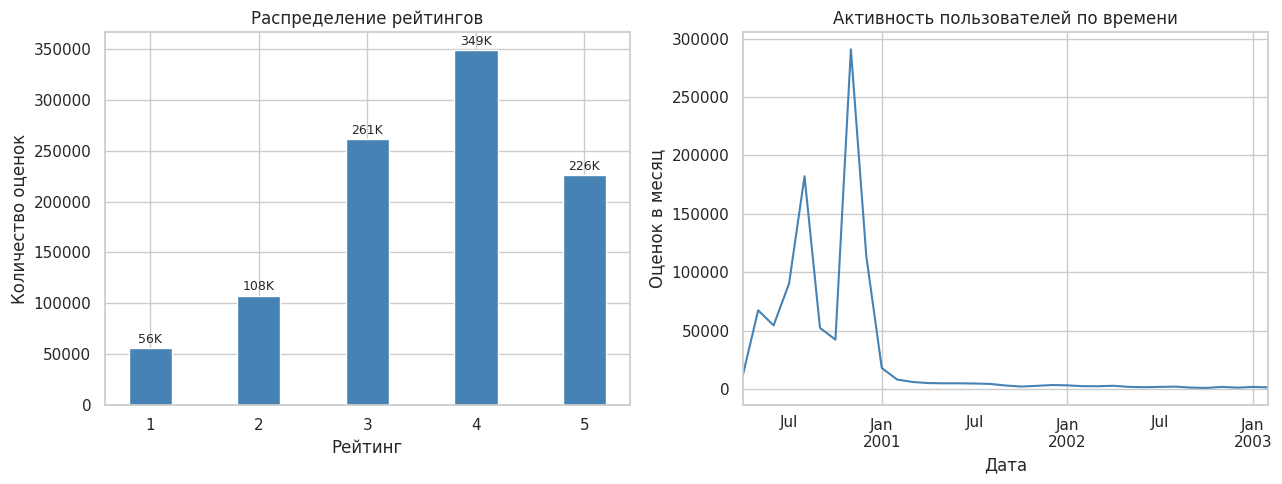

Средний рейтинг: 3.58
Медиана:         4.0


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Гистограмма рейтингов
rating_counts = ratings['rating'].value_counts().sort_index()
axes[0].bar(rating_counts.index, rating_counts.values, color='steelblue', width=0.4)
axes[0].set_xlabel('Рейтинг')
axes[0].set_ylabel('Количество оценок')
axes[0].set_title('Распределение рейтингов')
for x, y in zip(rating_counts.index, rating_counts.values):
    axes[0].text(x, y + 5000, f'{y/1000:.0f}K', ha='center', fontsize=9)

# Распределение по времени
ratings.set_index('datetime')['rating'].resample('M').count().plot(ax=axes[1], color='steelblue')
axes[1].set_xlabel('Дата')
axes[1].set_ylabel('Оценок в месяц')
axes[1].set_title('Активность пользователей по времени')

plt.tight_layout()
plt.savefig('../data/eda_ratings_dist.png', bbox_inches='tight')
plt.show()

print(f'Средний рейтинг: {ratings["rating"].mean():.2f}')
print(f'Медиана:         {ratings["rating"].median():.1f}')

## 3. Активность пользователей и фильмов (long-tail)

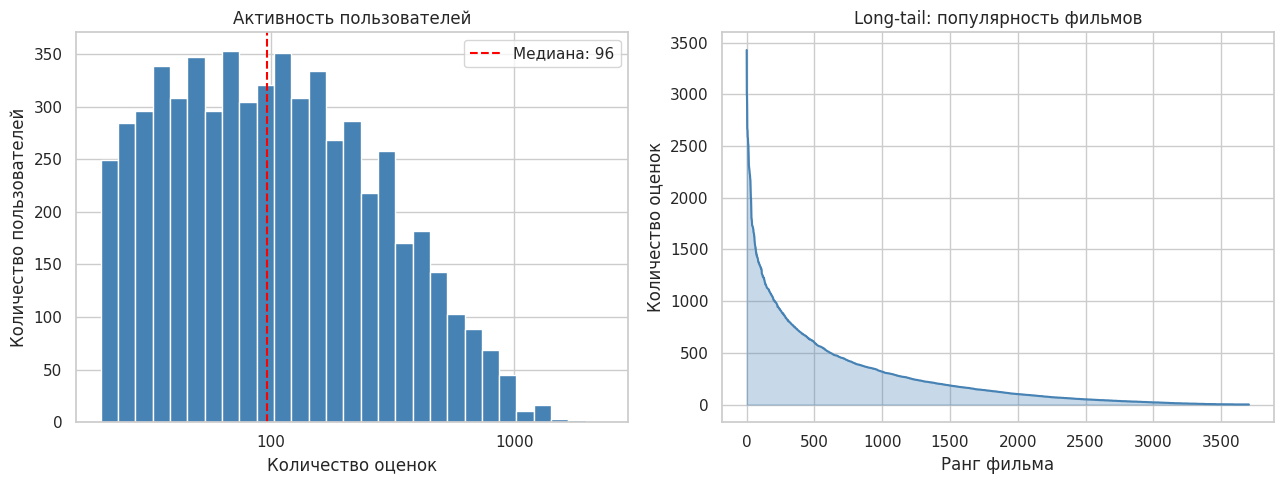

=== Активность пользователей ===
count    6040.0
mean      165.6
std       192.7
min        20.0
25%        44.0
50%        96.0
75%       208.0
max      2314.0
Name: n_ratings, dtype: float64

=== Популярность фильмов ===
count    3706.0
mean      269.9
std       384.0
min         1.0
25%        33.0
50%       123.5
75%       350.0
max      3428.0
Name: n_ratings, dtype: float64


In [12]:
user_activity = ratings.groupby('user_id')['rating'].count().rename('n_ratings')
item_popularity = ratings.groupby('movie_id')['rating'].count().rename('n_ratings')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Активность пользователей
bins = np.logspace(np.log10(user_activity.min()), np.log10(user_activity.max()), 30)
axes[0].hist(user_activity, bins=bins, color='steelblue', edgecolor='white')
axes[0].set_xscale('log')
axes[0].xaxis.set_major_formatter(FormatStrFormatter('%g'))
axes[0].set_xlabel('Количество оценок')
axes[0].set_ylabel('Количество пользователей')
axes[0].set_title('Активность пользователей')
axes[0].axvline(user_activity.median(), color='red', linestyle='--',
                label=f'Медиана: {user_activity.median():.0f}')
axes[0].legend()

# Популярность фильмов
sorted_pop = item_popularity.sort_values(ascending=False).reset_index(drop=True)
axes[1].plot(sorted_pop.values, color='steelblue')
axes[1].set_xlabel('Ранг фильма')
axes[1].set_ylabel('Количество оценок')
axes[1].set_title('Long-tail: популярность фильмов')
axes[1].fill_between(range(len(sorted_pop)), sorted_pop.values, alpha=0.3, color='steelblue')

plt.tight_layout()
plt.savefig('../data/eda_activity.png', bbox_inches='tight')
plt.show()

print('=== Активность пользователей ===')
print(user_activity.describe().round(1))
print()
print('=== Популярность фильмов ===')
print(item_popularity.describe().round(1))

## 4. Cold-start анализ

Cold-start - пользователи/фильмы с малым числом оценок.
Для RecSys это критично: коллаборативная фильтрация плохо работает на них.

In [18]:
# Cold-start пороги
user_thresholds = [25, 30, 35]
item_thresholds = [5, 10, 20]

print('Cold-start пользователи (менее N оценок):')
for t in user_thresholds:
    n_cold = (user_activity < t).sum()
    print(f'  < {t:2d} оценок: {n_cold:,} пользователей ({n_cold/n_users:.1%})')

print()
print('Cold-start фильмы (менее N оценок):')
for t in item_thresholds:
    n_cold = (item_popularity < t).sum()
    print(f'  < {t:2d} оценок: {n_cold:,} фильмов ({n_cold/n_items:.1%})')

Cold-start пользователи (менее N оценок):
  < 25 оценок: 416 пользователей (6.9%)
  < 30 оценок: 751 пользователей (12.4%)
  < 35 оценок: 1,021 пользователей (16.9%)

Cold-start фильмы (менее N оценок):
  <  5 оценок: 290 фильмов (7.8%)
  < 10 оценок: 446 фильмов (12.0%)
  < 20 оценок: 663 фильмов (17.9%)


## 5. Анализ жанров

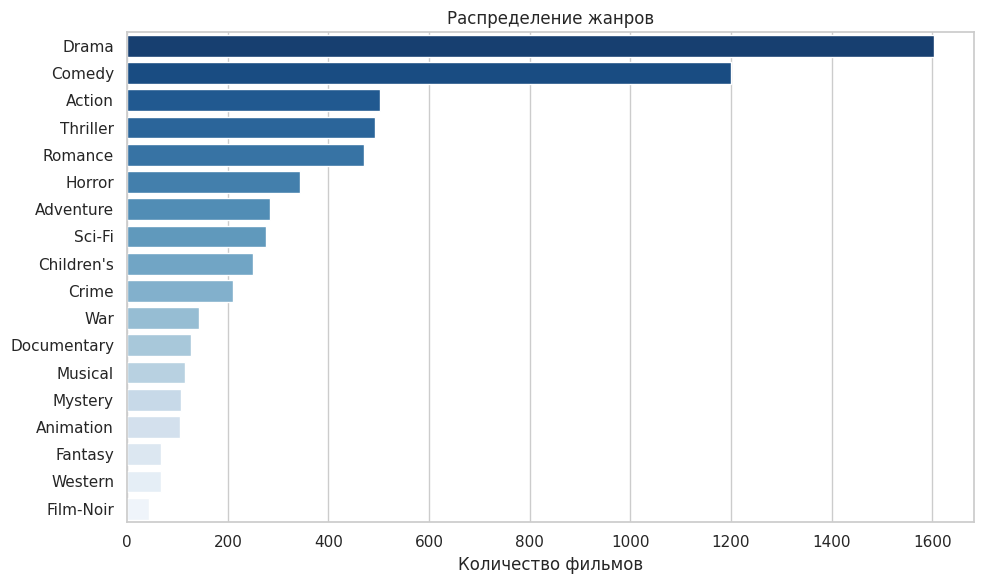

In [19]:
# Разворачиваем жанры (один фильм - несколько жанров)
genre_df = movies['genres'].str.split('|').explode().value_counts().reset_index()
genre_df.columns = ['genre', 'count']

plt.figure(figsize=(10, 6))
sns.barplot(data=genre_df, x='count', y='genre', palette='Blues_r')
plt.xlabel('Количество фильмов')
plt.ylabel('')
plt.title('Распределение жанров')
plt.tight_layout()
plt.savefig('../data/eda_genres.png', bbox_inches='tight')
plt.show()

In [21]:
# Средний рейтинг по жанрам
movies_ratings = ratings.merge(movies[['movie_id', 'genres']], on='movie_id')
genre_ratings = (
    movies_ratings['genres'].str.split('|')
    .explode()
    .reset_index()
    .merge(movies_ratings[['rating']], left_on='index', right_index=True)
    .groupby('genres')['rating']
    .agg(['mean', 'count'])
    .query('count > 500')
    .sort_values('mean', ascending=False)
    .round(2)
)

print('Средний рейтинг по жанрам:')
print(genre_ratings.to_string())

Средний рейтинг по жанрам:
             mean   count
genres                   
Film-Noir    4.08   18261
Documentary  3.93    7910
War          3.89   68527
Drama        3.77  354529
Crime        3.71   79541
Animation    3.68   43293
Mystery      3.67   40178
Musical      3.67   41533
Western      3.64   20683
Romance      3.61  147523
Thriller     3.57  189680
Comedy       3.52  356580
Action       3.49  257457
Adventure    3.48  133953
Sci-Fi       3.47  157294
Fantasy      3.45   36301
Children's   3.42   72186
Horror       3.22   76386


## 6. Temporal Split

**Почему не random split?**

Random split приводит к data leakage: мы обучаем модель на будущих оценках,
а предсказываем прошлые. В жизни всегда предсказываем будущее. Поэтому будем отправлять последние K оценок каждого пользователя в test, предпоследние в val.

In [24]:
# Сортируем по времени внутри каждого пользователя
ratings_sorted = ratings.sort_values(['user_id', 'timestamp'])

# Добавляем ранг оценки (от начала = 1, с конца = -1)
ratings_sorted['rank_from_end'] = ratings_sorted.groupby('user_id')['timestamp'] \
                                                 .rank(method='first', ascending=False)

N_VAL  = 3  # предпоследние N фильмов в val
N_TEST = 1  # последний фильм в test

test_df  = ratings_sorted[ratings_sorted['rank_from_end'] <= N_TEST]
val_df   = ratings_sorted[(ratings_sorted['rank_from_end'] > N_TEST) & 
                           (ratings_sorted['rank_from_end'] <= N_TEST + N_VAL)]
train_df = ratings_sorted[ratings_sorted['rank_from_end'] > N_TEST + N_VAL]

print(f'Train: {len(train_df):,} ({len(train_df)/n_ratings:.1%})')
print(f'Val:   {len(val_df):,}   ({len(val_df)/n_ratings:.1%})')
print(f'Test:  {len(test_df):,}  ({len(test_df)/n_ratings:.1%})')

train_df.to_parquet('../data/train.parquet', index=False)
val_df.to_parquet('../data/val.parquet', index=False)
test_df.to_parquet('../data/test.parquet', index=False)
movies.to_parquet('../data/movies.parquet', index=False)
users.to_parquet('../data/users.parquet', index=False)
ratings.to_parquet('../data/ratings.parquet', index=False)

print('\nДанные сохранены в ../data/')

Train: 976,049 (97.6%)
Val:   18,120   (1.8%)
Test:  6,040  (0.6%)

Данные сохранены в ../data/


## 7. Итог EDA

| Метрика | Значение |
|---|---|
| Пользователей | 6040 |
| Фильмов | 3706 |
| Оценок | 1000209 |
| Разреженность | ~95.5% |
| Средний рейтинг | 3.58 |
| Медиана оценок на пользователя | 96 |

**Выводы:**
- Высокая плотность данных для RecSys.
- Распределение популярности фильмов имеет тяжелый хвост. Это означает, что в данных силен popularity bias (смещение в сторону хитов).
- Cold-start незначителен (минимум 20 оценок на пользователя).